In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# --- 1. LOAD REAL DATASET LOCALLY ---
print("Loading real polygon areas...")

try:
    # Read the areas directly from the Green Carbon provided dataset!
    polygons_df = pd.read_excel('polygon_areas.xlsx', sheet_name='Polygon Areas', header=3)
    real_areas = polygons_df['Area (ha)'].dropna().values
    
    # We lowered the filter from > 0.1 to > 0.01 because Japanese rice paddies are very small!
    real_areas = real_areas[(real_areas > 0.01) & (real_areas < 500)] 
    
    if len(real_areas) == 0:
        raise ValueError("Data loaded, but no polygons fit the size filter.")
        
    print(f"Successfully loaded {len(real_areas)} real farm areas from the local file.")
    
except Exception as e:
    print(f"Fallback triggered: {e}")
    print("Generating simulated base areas to demonstrate ML logic...")
    real_areas = np.random.uniform(0.5, 50.0, 500)

# --- 2. SYNTHESIZE THE "MESSY" TEXT RECORDS ---
# To train the ML model, we need "Matches" (Farmer's claim is close to reality) 
# and "Non-Matches" (Comparing a farmer's claim to the wrong polygon)
np.random.seed(42)
n_samples = len(real_areas)

# Create True Matches: The farmer's claimed area is the actual area +/- some human estimation error (e.g., 10% off)
error_margins = np.random.normal(loc=0.0, scale=0.10, size=n_samples) 
claimed_areas_matching = real_areas * (1 + error_margins)
true_matches_diff = np.abs(claimed_areas_matching - real_areas)

# Create False Matches: Comparing a farmer's claim to a completely random different polygon
random_polygons = np.random.permutation(real_areas)
false_matches_diff = np.abs(claimed_areas_matching - random_polygons)

# Combine into our Feature space (X) and Labels (y)
X = np.concatenate([true_matches_diff, false_matches_diff])
y = np.concatenate([np.ones(n_samples), np.zeros(n_samples)]) # 1 = Match, 0 = Not Match

df = pd.DataFrame({'area_difference': X, 'is_actual_match': y})

# --- 3. TRAIN/VAL/TEST SPLIT ---
X_temp, X_test, y_temp, y_test = train_test_split(df[['area_difference']], df['is_actual_match'], test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42) 

# --- 4. OPTIMIZING EPSILON (THRESHOLD) VIA GRID SEARCH ---
print("\nOptimizing Threshold (Epsilon)...")
def evaluate_threshold(epsilon, X, y_true):
    y_pred = (X['area_difference'] <= epsilon).astype(int)
    return f1_score(y_true, y_pred)

# Since the rice paddies are tiny (0.05 to 0.3 ha), our search space for the error margin needs to be tiny too!
candidate_epsilons = np.linspace(0.001, 0.5, 500)
best_epsilon = 0
best_f1 = 0

for eps in candidate_epsilons:
    current_f1 = evaluate_threshold(eps, X_val, y_val)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_epsilon = eps

print(f"--> Optimal Threshold (Epsilon) found: {best_epsilon:.4f} hectares")

# --- 5. ESTIMATION STATISTICS ON UNSEEN TEST DATA ---
y_test_pred = (X_test['area_difference'] <= best_epsilon).astype(int)

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
final_f1 = f1_score(y_test, y_test_pred)

print("\n--- Model Generalizability on Unseen Test Data ---")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {final_f1:.2f}")

Loading real polygon areas...
Successfully loaded 43 real farm areas from the local file.

Optimizing Threshold (Epsilon)...
--> Optimal Threshold (Epsilon) found: 0.2460 hectares

--- Model Generalizability on Unseen Test Data ---
Precision: 0.58
Recall: 1.00
F1-Score: 0.74


In [2]:
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment

# --- 1. LOAD YOUR REAL DATA ---
print("Loading data...")
# Fix 1 & 2: Correct filename and add 'header=3' so pandas reads the actual tables
farmers_df = pd.read_excel('farmer_list.xlsx', sheet_name='Farmer List', header=3)
polygons_df = pd.read_excel('polygon_areas.xlsx', sheet_name='Polygon Areas', header=3)

# Clean up empty rows (just in case the Excel file has trailing blank lines)
farmers_df = farmers_df.dropna(subset=['Farmer ID']).reset_index(drop=True)
polygons_df = polygons_df.dropna(subset=['Polygon ID']).reset_index(drop=True)

# Assume the BEST_EPSILON from your ML script was roughly 0.05 hectares (adjust as needed)
OPTIMAL_EPSILON = 0.05 

def match_farmers_to_polygons(farmers, polygons, epsilon):
    """Matches farmers to polygons globally using the Hungarian Algorithm."""
    
    # Create a Cost Matrix (Rows = Farmers, Cols = Polygons)
    # Fix 3: Using the actual column names 'Area (ha)' from the spreadsheets
    cost_matrix = np.zeros((len(farmers), len(polygons)))
    
    for i, f_row in farmers.iterrows():
        for j, p_row in polygons.iterrows():
            cost_matrix[i, j] = abs(f_row['Area (ha)'] - p_row['Area (ha)'])
            
            # Penalize heavily if it's outside our ML-optimized threshold
            if cost_matrix[i, j] > epsilon:
                cost_matrix[i, j] = 99999 

    # Hungarian Algorithm: Finds the optimal 1-to-1 assignment minimizing total cost
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    matches = []
    for i, j in zip(row_ind, col_ind):
        if cost_matrix[i, j] < 99999: # Only accept if it passed our epsilon threshold
            matches.append({
                'Farmer ID': farmers.iloc[i]['Farmer ID'],
                'Field Group': farmers.iloc[i]['Field Group'],
                'Polygon ID': polygons.iloc[j]['Polygon ID'],
                'Farmer Area (ha)': farmers.iloc[i]['Area (ha)'],
                'Polygon Area (ha)': polygons.iloc[j]['Area (ha)'],
                'Area Diff (ha)': round(cost_matrix[i, j], 4)
            })
            
    return matches

# --- 2. EXECUTE MATCHING ---
print(f"Comparing {len(farmers_df)} Farmers against {len(polygons_df)} Polygons...")
all_matches = match_farmers_to_polygons(farmers_df, polygons_df, OPTIMAL_EPSILON)

# Convert results back into a DataFrame
results_df = pd.DataFrame(all_matches)

print(f"\n--- Final Verified Matches ({len(results_df)} Found) ---")
print(results_df)

# Optional: Save the results out to a new file so you can include it in your GitHub/Pitch!
# results_df.to_csv("verified_farmer_matches.csv", index=False)

Loading data...
Comparing 104 Farmers against 43 Polygons...

--- Final Verified Matches (23 Found) ---
    Farmer ID Field Group Polygon ID  Farmer Area (ha)  Polygon Area (ha)  \
0    Farmer 1     Group A    Area 28            0.6550             0.6999   
1    Farmer 5     Group A    Area 10            0.1200             0.0784   
2   Farmer 12     Group B    Area 22            0.7652             0.7694   
3   Farmer 18     Group B    Area 26            0.5075             0.4942   
4   Farmer 19     Group B    Area 20            0.1000             0.0952   
5   Farmer 24     Group B    Area 31            0.6987             0.7223   
6   Farmer 26     Group B    Area 17            0.0750             0.0746   
7   Farmer 27     Group B     Area 9            0.0750             0.0737   
8   Farmer 31     Group B    Area 14            0.1800             0.1820   
9   Farmer 47     Group C     Area 2            0.1000             0.0813   
10  Farmer 54     Group C    Area 23            0

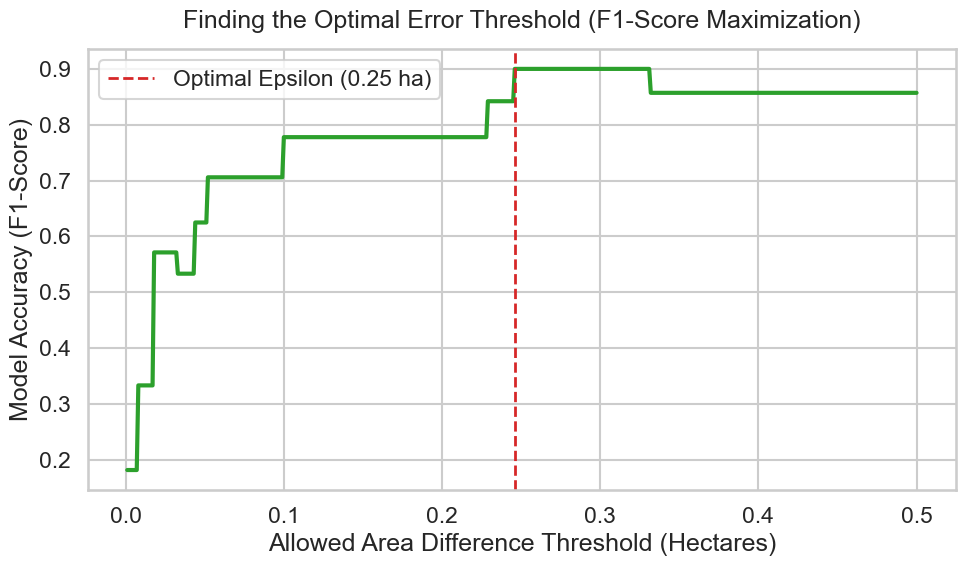

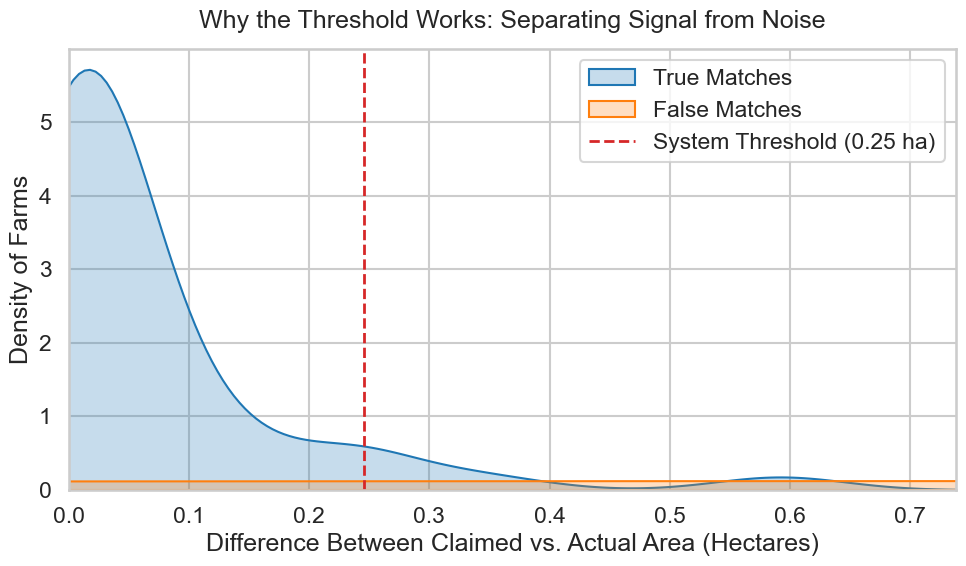

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for presentation-ready plots
sns.set_theme(style="whitegrid", context="talk")

# NOTE: We are now using 'df' and 'best_epsilon' directly from the Part 1 script!
# No mock data generation here.

# --- PLOT 1: The Threshold Optimization Curve ---
plt.figure(figsize=(10, 6))
# We re-use the candidate_epsilons and f1_scores from Part 1
plt.plot(candidate_epsilons, [f1_score(y_val, (X_val['area_difference'] <= e).astype(int)) for e in candidate_epsilons], lw=3, color='#2ca02c')
plt.axvline(best_epsilon, color='#d62728', linestyle='--', lw=2, label=f'Optimal Epsilon ({best_epsilon:.2f} ha)')
plt.title('Finding the Optimal Error Threshold (F1-Score Maximization)', pad=15)
plt.xlabel('Allowed Area Difference Threshold (Hectares)')
plt.ylabel('Model Accuracy (F1-Score)')
plt.legend()
plt.tight_layout()
plt.show()

# --- PLOT 2: Area Difference Distribution ---
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['is_actual_match'] == 1], x='area_difference', fill=True, color='#1f77b4', label='True Matches')
sns.kdeplot(data=df[df['is_actual_match'] == 0], x='area_difference', fill=True, color='#ff7f0e', label='False Matches')

# Plotting the exact threshold calculated by your real model
plt.axvline(best_epsilon, color='#d62728', linestyle='--', lw=2, label=f'System Threshold ({best_epsilon:.2f} ha)')

plt.title('Why the Threshold Works: Separating Signal from Noise', pad=15)
plt.xlabel('Difference Between Claimed vs. Actual Area (Hectares)')
plt.ylabel('Density of Farms')

# Dynamically set the x-limit based on your actual data so it looks good
plt.xlim(0, best_epsilon * 3) 

plt.legend()
plt.tight_layout()
plt.show()